# 03 · Optimizacion global de asignacion y secuenciacion — LineWise DAMM

## Formulacion del problema

Dado un conjunto de SKUs a producir durante una semana, con volumen total en HL fijo por SKU,
resolver simultaneamente dos decisiones:

- **Asignacion**: que linea produce cada SKU.
- **Secuencia**: en que orden cronologico se produce cada SKU dentro de su linea.

La OF/MES es el nexo operativo: el coste de cada arco `SKU_origen -> SKU_destino` sale del post-mortem, donde cada cambio se interpreta revisando la OF anterior. La capacidad usa produccion (`HL / throughput`) mas **tiempo de cambio teorico**, coherente con la tabla de cambio de formato.

### Variables de decision

- `y[l,i]`: 1 si la linea `l` produce el SKU `i`.
- `x[l,i,j]`: 1 si en la linea `l` el SKU `i` va inmediatamente antes que `j`.
- `u[l,i]`: posicion del SKU `i` en la secuencia de la linea `l` (MTZ / prioridades).

### Funcion objetivo

Minimizar la degradacion total de OEE aprendida del historico:

$$\min \sum_{l,i,j} x[l,i,j] \cdot cost[l,i,j]$$

### Restricciones clave

1. Asignacion unica de cada SKU.
2. Conservacion de flujo con inicio/fin virtual por linea y eliminacion de subtours via MTZ.
3. Incompatibilidad estricta: SKUs que contienen `12` no pueden ir a L14 ni L17.
4. Capacidad semanal por linea.
5. Urgencias: asignacion forzada y posicion temprana (`u <= 2`).

### Solver

Google OR-Tools CP-SAT con `max_time_in_seconds = 60.0`. Se proporciona un hint heuristico factible solo para arrancar la busqueda; la solucion final la decide CP-SAT.


## 0 · Modelo de datos operativo: OF/MES como nexo

Este notebook sigue la arquitectura de datos de planta: la OF/MES es el nexo entre cambios, OEE, volumen y tiempos. La lectura operativa clave es que un cambio no vive aislado: para clasificarlo y medir su efecto hay que revisar la OF anterior en la misma linea y ventana temporal.

```mermaid
flowchart LR
    CF["Cambio formato"] -.-> TCT["Tiempo cambio teorico"]
    ML["Mantenimiento y limpiezas"] -.-> TCT
    TCT <--> OF["MES / OF (nexo)"]
    CAM["Cambios"] -.-> OF
    CAM --> TC["Tipo de cambio"]
    TC --> PREV["Revisar OF anterior"]
    OF -.-> OEE["OEE"]
    OF -.-> T["Tiempo"]
    OF -.-> V["Volumen"]
    OEE --> CYN["Cambio si/no"]
    OEE --> KPI["%OEE / %Rendimiento"]
    V --> V2["HL / UDS / OEE"]
    T --> T2["H Tot / Par Tot / PNP / Limpieza / Idle / %Disp / %Calidad / %Rend"]
```

Formulas usadas como control semantico:

- `OEE = Disponibilidad x Rendimiento x Calidad`
- `Disponibilidad = Tiempo funcionamiento / Tiempo planificado`
- `Rendimiento = (Tiempo ciclo ideal x Produccion total) / Tiempo funcionamiento`
- `Calidad = Produccion buena / Produccion total`
- `Tiempo cambio = H Tot - (PNP + Limpieza + Idle)`; `Idle` se separa para no imputarlo automaticamente al OEE.

En optimizacion, la matriz `Line/SKU_origen/SKU_destino` sale de revisar la OF anterior y entra como coste de `x[l,i,j]`.


In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from typing import List, Tuple, Dict, Optional

from analisis_postmorten.post_mortem import PostMortemAnalyzer
from analisis_postmorten.data_loaders import (
    load_all_operations,
    load_diario_hl,
    weekly_demand_from_diario,
)
from analisis_postmorten.scheduling_cp_sat import (
    DEFAULT_SETUP_HOURS,
    DEFAULT_MINOR_CHANGEOVER_HOURS,
    SCALE,
    build_cost_matrix,
    build_theoretical_changeover_matrix,
    estimate_hours,
    prepare_throughput,
    run_cpsat_global_mtz,
    run_fallback_heuristic,
    sequence_cost,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
DATA_DIR = Path('../OPERACIONS')

# Horas disponibles por semana por línea (3 turnos x 5 dias laborables x 8h = 120h,
# menos tiempos de limpieza y mantenimiento estimados)
HOURS_PER_WEEK = {'14': 110, '17': 115, '19': 115}
print("Configuracion de capacidad semanal:", HOURS_PER_WEEK, "horas/linea")
print(f"Escalado CP-SAT: SCALE={SCALE:,} | setup teorico menor={DEFAULT_MINOR_CHANGEOVER_HOURS:.1f}h | fallback formato={DEFAULT_SETUP_HOURS:.1f}h")

Configuracion de capacidad semanal: {'14': 110, '17': 115, '19': 115} horas/linea
Escalado CP-SAT: SCALE=10,000 | setup teorico menor=0.5h | fallback formato=1.5h


## 1 · Cargar datos y ejecutar pipeline post-mortem

In [2]:
dfs = load_all_operations(DATA_DIR)
print(f"OEE: {len(dfs['oee'])} OFs | tren unicos: {sorted(dfs['oee']['tren'].dropna().unique())}")

analyzer = PostMortemAnalyzer(
    df_oee=dfs['oee'], df_cambios=dfs['cam'], df_mantenimiento=dfs['mant'],
    df_tiempo=dfs['tiem'], df_volumen=dfs['vol'],
)
metrics = analyzer.run_full_pipeline()
matrices = analyzer.build_transition_matrices()
print("\nPipeline post-mortem completado")

OEE: 2141 OFs | tren unicos: ['14', '17', '19']
  PostMortemAnalyzer — Pipeline completo
[clean_and_isolate_maintenance] OFs contaminadas (>20%): 293/2141 (13.7%)
  → imputadas por mediana SKU-línea (>50%): 105
[build_transition_matrices] Línea 14: 259 transiciones únicas (63 SKUs origen, 63 SKUs destino)
[build_transition_matrices] Línea 17: 517 transiciones únicas (76 SKUs origen, 75 SKUs destino)
[build_transition_matrices] Línea 19: 547 transiciones únicas (108 SKUs origen, 108 SKUs destino)
[build_directed_graph] Línea 14: 66 nodos, 259 aristas
[build_directed_graph] Línea 17: 76 nodos, 517 aristas
[build_directed_graph] Línea 19: 111 nodos, 547 aristas
[detect_black_spots] 20 black spots detectados (umbral degradación > μ + 1.5σ, mín. 2 ocurrencias)
[export_explainability_metrics] Métricas de explicabilidad generadas:
  · top_black_spots: 10 filas
  · critical_nodes: 20 filas
  · weekly_oee_loss: 152 filas
  · line_summary: 3 filas
[build_transition_matrices] Línea 14: 259 transi

## 2 · Cargar demanda de la semana test (Diario Hl_Planif)

In [3]:
df_diario = load_diario_hl(DATA_DIR / 'Diario Hl_Planif.xlsx')
assert not df_diario['sku'].str.lower().str.contains('total', na=False).any(), \
    "El Diario contiene filas TOTAL mal parseadas como SKU"

demanda_semanal = weekly_demand_from_diario(df_diario)

print(f"Demanda semanal - {df_diario['fecha'].min().date()} al {df_diario['fecha'].max().date()}")
print(f"  SKUs unicos: {demanda_semanal['sku'].nunique()}  |  HL total: {demanda_semanal['hl_total'].sum():,.0f}")
print()
print("Carga original por linea (antes de optimizar):")
print(df_diario.groupby('tren').agg(n_skus=('sku','nunique'), hl=('hl_planificado','sum')).round(0))
print()
print(demanda_semanal.to_string(index=False))

Demanda semanal - 2026-05-18 al 2026-05-21
  SKUs unicos: 33  |  HL total: 36,933

Carga original por linea (antes de optimizar):
      n_skus       hl
tren                 
14         6   7441.0
17        13  14391.0
19        14  15102.0

tren      sku    hl_total original_tren  row_order first_fecha
  14 ED13LMCM  475.200012            14          0  2026-05-18
  14 ED13LTMC  253.440002            14          1  2026-05-18
  14 ED13LTNN 4466.879944            14          2  2026-05-19
  14  FDT13LT 1433.520020            14          5  2026-05-18
  14 FDT13LTM  237.600006            14          6  2026-05-18
  14 VO13LTMP  574.200012            14          7  2026-05-21
  17   DL13LT 3117.870117            17          8  2026-05-19
  17 ED13P24N  396.000000            17          9  2026-05-18
  17 FD13LTNN 1393.919983            17         10  2026-05-18
  17  FDL13LN  720.719971            17         12  2026-05-19
  17 KE13LTNN  625.680008            17         13  2026-05-20
  1

## 3 · Construir matriz de costes de secuenciación

In [4]:
# Matrices de coste OEE y tiempos auxiliares compartidos por CP-SAT y fallback.
throughput = prepare_throughput(dfs)

all_skus_week = demanda_semanal['sku'].tolist()

# SOBREESCRIBIR matrices usando el modelo de grafos suavizado bilinear
matrices = analyzer.build_sophisticated_matrices(all_skus_week)
PRIORITY_ORDERS = [] # Definir para evitar NameError en celdas posteriores
print("Matrices de coste, changeover y throughput preparadas")
print("\nThroughput mediano por linea (HL/h):")
print(throughput.groupby('tren')['hl_per_h'].median().round(1))
print("\nCobertura historica de costes para la semana test:")
for line in ['14', '17', '19']:
    mat = build_cost_matrix(line, all_skus_week, matrices)
    co = build_theoretical_changeover_matrix(line, all_skus_week)
    offdiag = len(all_skus_week) * (len(all_skus_week) - 1)
    hist = 0
    if line in matrices:
        raw = matrices[line]['oee_degradation']
        for origin in all_skus_week:
            for dest in all_skus_week:
                if origin != dest and origin in raw.index and dest in raw.columns and pd.notna(raw.loc[origin, dest]):
                    hist += 1
    print(f"  L{line}: coste {mat.shape[0]}x{mat.shape[1]} | historico {hist}/{offdiag} | "
          f"changeover teorico mediana {co.replace(0, np.nan).stack().median():.2f}h")

Matrices de coste, changeover y throughput preparadas

Throughput mediano por linea (HL/h):
tren
14     83.0
17    144.3
19    141.0
Name: hl_per_h, dtype: float64

Cobertura historica de costes para la semana test:
  L14: coste 33x33 | historico 5/1056 | changeover teorico mediana 0.50h
  L17: coste 33x33 | historico 55/1056 | changeover teorico mediana 0.50h
  L19: coste 33x33 | historico 11/1056 | changeover teorico mediana 0.50h


## 4 · Utilidades de coste, throughput y arranque heuristico

In [5]:
# Las funciones de secuenciacion y estimacion horaria viven en scheduling_cp_sat.py.
# Se mantienen importadas para que las celdas posteriores y el jurado puedan inspeccionarlas.
print("Funciones de optimizacion importadas desde analisis_postmorten.scheduling_cp_sat")

Funciones de optimizacion importadas desde analisis_postmorten.scheduling_cp_sat


## 5.1 · Modelo CP-SAT exacto: asignacion + secuencia

El modelo usa la lectura del diagrama de planta:

- `y[l,i]`: asigna cada SKU/OF planificada a una unica linea.
- `x[l,i,j]`: activa una transicion inmediata y, por tanto, aplica el coste aprendido de revisar la OF anterior.
- `u[l,i]`: posicion en la ruta de la linea para eliminar subtours y forzar urgencias tempranas.
- Capacidad: produccion (`HL / throughput`) + tiempo de cambio entre OFs consecutivas.


In [11]:
# Modelo exacto global: asignacion + secuenciacion simultaneas con CP-SAT y MTZ.
# Si OR-Tools no esta instalado, se conserva un fallback heuristico local para que
# el notebook siga siendo ejecutable, pero la solucion entregable es CP-SAT.

results = run_cpsat_global_mtz(
    demanda_semanal=demanda_semanal,
    matrices=matrices,
    throughput=throughput,
    hours_per_week=HOURS_PER_WEEK,
    priority_orders=PRIORITY_ORDERS,
    setup_hours=DEFAULT_SETUP_HOURS,
    time_limit=60.0,
    log_search_progress=False,
)

if results is None:
    print("\nFallback heuristico por linea: OR-Tools no disponible o CP-SAT sin solucion factible.")
    results = run_fallback_heuristic(
        demanda_semanal=demanda_semanal,
        matrices=matrices,
        throughput=throughput,
        hours_per_week=HOURS_PER_WEEK,
        priority_orders=PRIORITY_ORDERS,
        setup_hours=DEFAULT_SETUP_HOURS,
    )

schedule_df = results.get('_schedule_df', pd.DataFrame())
print("\nCarga optimizada por linea:")
summary_rows = []
for line in ['14', '17', '19']:
    if line not in results:
        continue
    r = results[line]
    summary_rows.append({
        'linea': line,
        'skus': len(r['seq_optimized']),
        'prod_h': r['prod_hours_estimated'],
        'setup_h': r['setup_hours_estimated'],
        'total_h': r['hours_estimated'],
        'capacidad_h': HOURS_PER_WEEK[line],
        'capacity_ok': r['capacity_ok'],
        'coste_oee': r['cost_optimized'],
    })
summary_cp = pd.DataFrame(summary_rows)
print(summary_cp.to_string(index=False, float_format='{:.2f}'.format))

CP-SAT MTZ: 33 SKUs x 3 lineas | limite 60s
Estado: OPTIMAL | objetivo: -1.0809
L14: 11 SKUs |   81.7h / 110h OK | OEE deg -0.1126
L17:  9 SKUs |   99.1h / 115h OK | OEE deg -0.7738
L19: 13 SKUs |  111.6h / 115h OK | OEE deg -0.1946

Carga optimizada por linea:
linea  skus  prod_h  setup_h  total_h  capacidad_h  capacity_ok  coste_oee
   14    11   76.73     5.00    81.73          110         True      -0.11
   17     9   95.10     4.00    99.10          115         True      -0.77
   19    13  105.60     6.00   111.60          115         True      -0.19


## 6 · Visualización: Gantt de secuencia optimizada vs. baseline

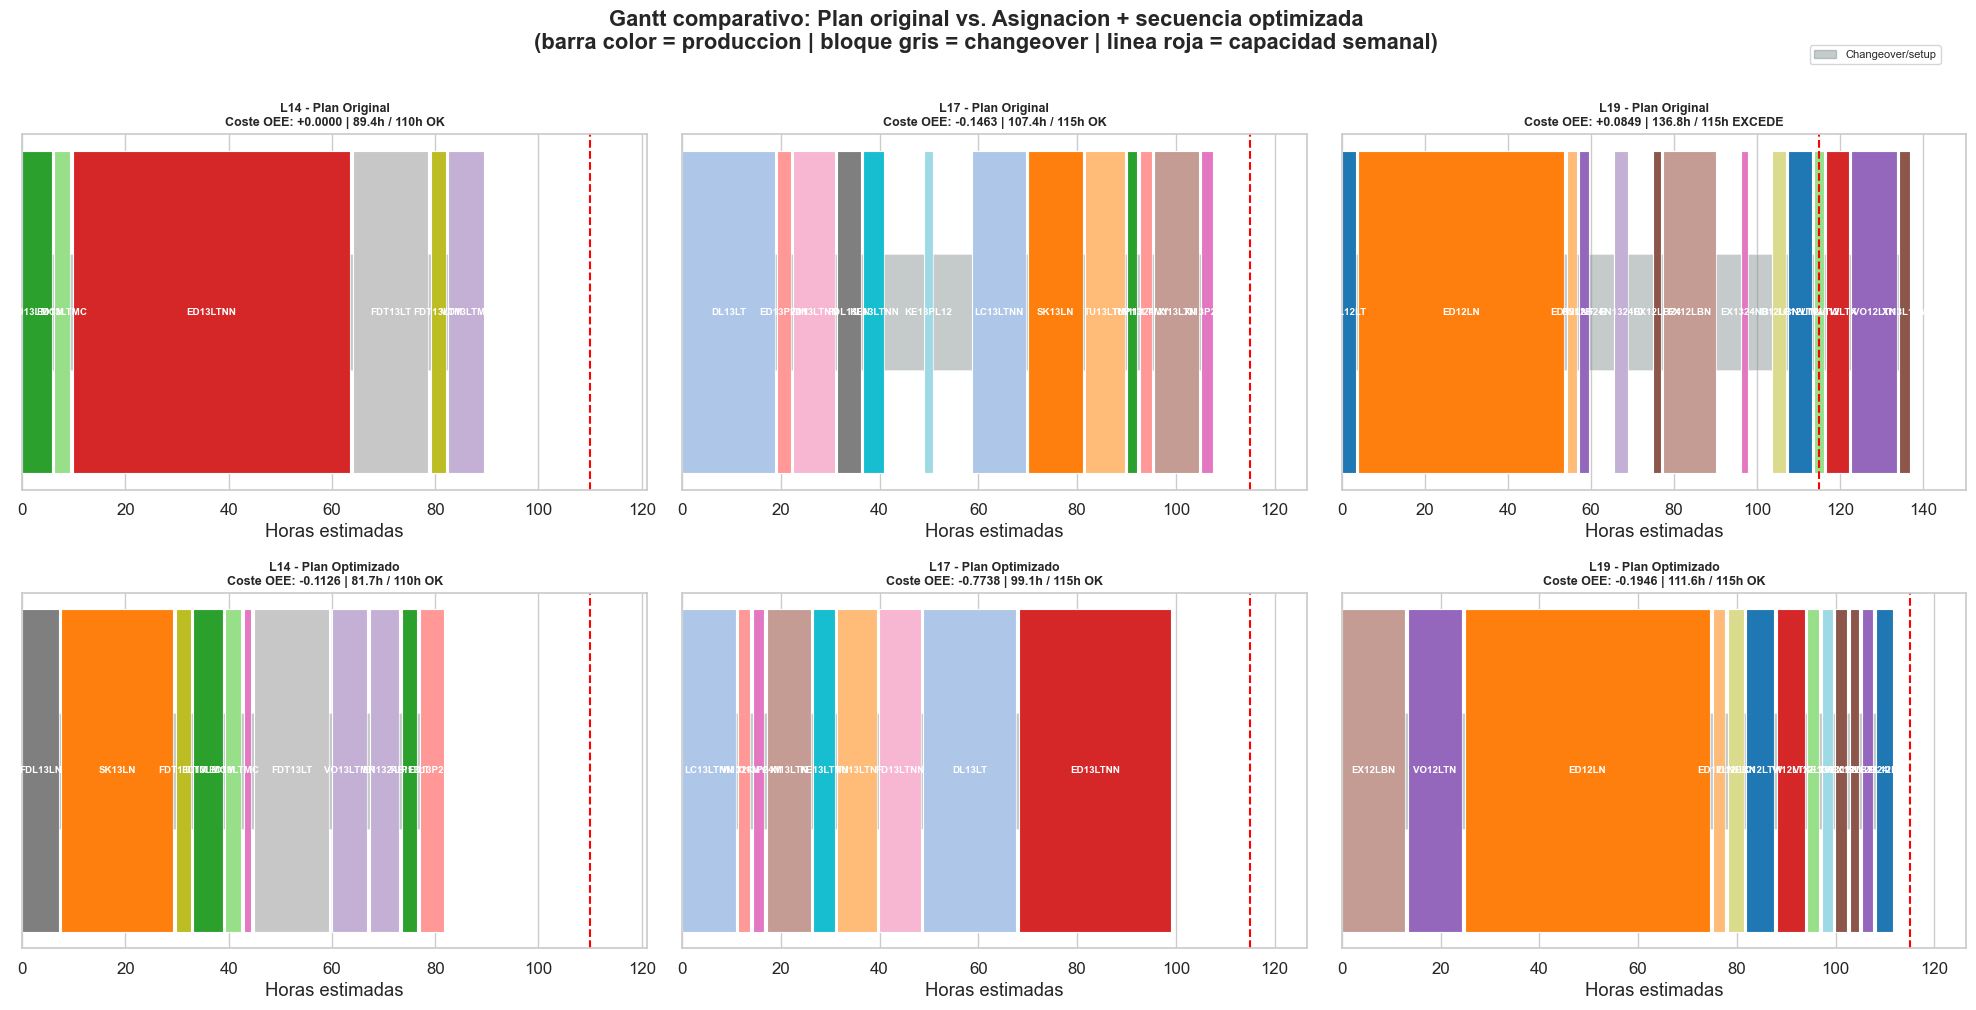

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
colors_sku = {}
all_skus = sorted(set(demanda_semanal['sku']).union(set(schedule_df['sku']) if not schedule_df.empty else set()))
palette = plt.cm.tab20.colors
for i, sku in enumerate(all_skus):
    colors_sku[sku] = palette[i % len(palette)]

for col, line in enumerate(['14', '17', '19']):
    if line not in results:
        continue
    res = results[line]

    panels = [
        ('baseline_details', 'Plan Original', res['cost_baseline'], res['baseline_hours_estimated']),
        ('details', 'Plan Optimizado', res['cost_optimized'], res['hours_estimated']),
    ]
    for row, (detail_key, label, cost_value, total_h) in enumerate(panels):
        ax = axes[row][col]
        det = res.get(detail_key, pd.DataFrame()).copy()
        if det.empty:
            ax.text(0.5, 0.5, 'Sin SKUs', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue

        for _, item in det.iterrows():
            setup_h = float(item.get('setup_h', 0.0))
            setup_start = float(item.get('setup_start_h', max(item['start_h'] - setup_h, 0)))
            if setup_h > 0:
                ax.barh(0, setup_h, left=setup_start, height=0.18,
                        color='#7f8c8d', alpha=0.45, edgecolor='white', linewidth=0.5)
            width = float(item['prod_h'])
            ax.barh(0, width, left=float(item['start_h']), height=0.5,
                    color=colors_sku.get(item['sku'], 'gray'), edgecolor='white', linewidth=0.8)
            if width > 1.5:
                ax.text(float(item['start_h']) + width / 2, 0, str(item['sku'])[:8],
                        ha='center', va='center', fontsize=7, fontweight='bold', color='white')

        cap = HOURS_PER_WEEK[line]
        ax.axvline(cap, color='red', linestyle='--', lw=1.5)
        ax.set_xlim(0, max(cap * 1.1, float(total_h) * 1.1, 1.0))
        ax.set_yticks([])
        ax.set_xlabel('Horas estimadas')
        cap_flag = 'OK' if float(total_h) <= cap + 1e-6 else 'EXCEDE'
        ax.set_title(
            f'L{line} - {label}\nCoste OEE: {cost_value:+.4f} | {total_h:.1f}h / {cap}h {cap_flag}',
            fontweight='bold', fontsize=9,
        )

setup_patch = mpatches.Patch(color='#7f8c8d', alpha=0.45, label='Changeover/setup')
fig.legend(handles=[setup_patch], loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=8)
plt.suptitle(
    'Gantt comparativo: Plan original vs. Asignacion + secuencia optimizada\n'
    '(barra color = produccion | bloque gris = changeover | linea roja = capacidad semanal)',
    fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.show()

## 7 · Resumen de impacto y mejora estimada

In [13]:
print("=" * 72)
print("  RESUMEN DE OPTIMIZACION - Semana 18-24 Mayo 2026")
print("=" * 72)

bs_df = analyzer.detect_black_spots()
bs_ok = 'tren' in bs_df.columns and 'sku_prev' in bs_df.columns

for line in ['14', '17', '19']:
    if line not in results:
        continue
    r = results[line]
    cap = HOURS_PER_WEEK[line]
    cap_flag = 'OK' if r['capacity_ok'] else 'EXCEDE CAPACIDAD'

    print(f"\n{'-'*72}")
    print(f"  LINEA {line}")
    print(f"{'-'*72}")
    print(f"  Coste degradacion OEE original : {r['cost_baseline']:+.4f}")
    print(f"  Coste degradacion OEE optimiz. : {r['cost_optimized']:+.4f}")
    print(f"  Horas produccion/setup/total   : {r['prod_hours_estimated']:.1f}h / "
          f"{r['setup_hours_estimated']:.1f}h / {r['hours_estimated']:.1f}h")
    print(f"  Capacidad semanal              : {r['hours_estimated']:.1f}h / {cap}h  {cap_flag}")

    moved = []
    det = r['details']
    if not det.empty and 'original_tren' in det.columns:
        moved = det[~det['original_tren'].astype(str).str.split(',').apply(lambda xs: line in xs)]['sku'].tolist()
    if moved:
        print(f"  SKUs reasignados a L{line}: {', '.join(moved)}")

    print("\n  Secuencia recomendada:")
    seq = r['seq_optimized']
    for _, item in det.iterrows():
        i = int(item['sequence_order']) - 1
        sku = item['sku']
        if i < len(seq) - 1:
            nxt = seq[i + 1]
            deg = item.get('cost_to_next', np.nan)
            arrow = f"-> {nxt}  [deg: {deg:+.3f}]" if pd.notna(deg) else f"-> {nxt}"
        else:
            arrow = "(fin)"

        flags = []
        if item.get('priority_tipo'):
            flags.append(str(item['priority_tipo']).upper())
        if bs_ok:
            mask = (bs_df['tren'].astype(str) == line) & (bs_df['sku_prev'] == sku)
            if mask.any():
                flags.append('BLACK SPOT origen')
        flag_txt = f"  [{' | '.join(flags)}]" if flags else ""

        print(f"    {int(item['sequence_order']):2d}. {sku:<30} "
              f"{item['hl']:>7.0f} HL  prod {item['prod_h']:>5.1f}h  "
              f"setup {item['setup_h']:>4.1f}h  {arrow}{flag_txt}")

print(f"\n{'-'*72}")
print("Interpretacion: coste OEE positivo = degradacion esperada; coste negativo = mejora historica neta.")
print("Las filas grises del Gantt representan changeovers incluidos en la restriccion de capacidad.")

  RESUMEN DE OPTIMIZACION - Semana 18-24 Mayo 2026
[detect_black_spots] 20 black spots detectados (umbral degradación > μ + 1.5σ, mín. 2 ocurrencias)

------------------------------------------------------------------------
  LINEA 14
------------------------------------------------------------------------
  Coste degradacion OEE original : +0.0000
  Coste degradacion OEE optimiz. : -0.1126
  Horas produccion/setup/total   : 76.7h / 5.0h / 81.7h
  Capacidad semanal              : 81.7h / 110h  OK
  SKUs reasignados a L14: FDL13LN, SK13LN, EX1324NB, EN1324BI, TUP13LT, ED13P24N

  Secuencia recomendada:
     1. FDL13LN                            721 HL  prod   7.1h  setup  0.0h  -> SK13LN  [deg: -0.113]
     2. SK13LN                            1927 HL  prod  21.7h  setup  0.5h  -> FDT13LTM  [deg: +0.000]
     3. FDT13LTM                           238 HL  prod   2.9h  setup  0.5h  -> ED13LMCM  [deg: +0.000]
     4. ED13LMCM                           475 HL  prod   5.7h  setup  0.5h  -> E

In [15]:
# Tabla detallada de la secuencia optimizada de L17 y vista global auditable.
if '17' in results:
    print("\nDetalle secuencia optimizada Linea 17:")
    det = results['17']['details'].copy()
    cols = [
        'sequence_order', 'sku', 'original_tren', 'hl', 'throughput_hl_h',
        'setup_h', 'prod_h', 'start_h', 'end_h', 'priority_tipo', 'cost_to_next'
    ]
    cols = [c for c in cols if c in det.columns]
    print(det[cols].to_string(index=False, float_format='{:.2f}'.format))

if not schedule_df.empty:
    print("\nSchedule optimizado global:")
    cols = ['line', 'sequence_order', 'sku', 'original_tren', 'hl', 'setup_h', 'prod_h', 'start_h', 'end_h']
    print(schedule_df[cols].sort_values(['line', 'sequence_order']).to_string(index=False, float_format='{:.2f}'.format))


Detalle secuencia optimizada Linea 17:
 sequence_order      sku original_tren      hl  throughput_hl_h  setup_h  prod_h  start_h  end_h priority_tipo  cost_to_next
              1 LC13LTNN            17 1789.92           164.80     0.00   10.86     0.00  10.86                        0.02
              2 VI1324MY            17  356.40           144.34     0.50    2.47    11.36  13.83      urgencia          0.00
              3 XI13P24M            17  396.00           173.31     0.50    2.28    14.33  16.62                       -0.07
              4  XI13LTN            17 1631.52           181.59     0.50    8.98    17.12  26.10                       -0.28
              5 KE13LTNN            17  625.68           145.48     0.50    4.30    26.60  30.90                       -0.21
              6  TU13LTN            17 1425.60           177.76     0.50    8.02    31.40  39.42                       -0.08
              7 FD13LTNN            17 1393.92           165.79     0.50    8.41    3